**Building a Churn Prediction Model**

What we're doing: Using the RFM scores to predict whether a customer will churn (stop buying). We'll label customers as:
Churned = 1 → Recency > 180 days (haven't bought in 6 months)
Active = 0 → Recency ≤ 180 days 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Data/uk_retail.csv", parse_dates=["InvoiceDate"])

In [2]:
split_date = pd.Timestamp("2011-06-01")

past = df[df["InvoiceDate"] < split_date]
future = df[df["InvoiceDate"] >= split_date]

print("Past rows:", past.shape[0])
print("Future rows:", future.shape[0])

Past rows: 500897
Future rows: 224399


In [3]:
reference_date = split_date

rfm = past.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

rfm["Revenue_per_Order"] = rfm["Monetary"] / rfm["Frequency"]
rfm["Is_OneTime_Buyer"] = (rfm["Frequency"] == 1).astype(int)

print(rfm.shape)

(4520, 6)


In [4]:
future_customers = set(future["Customer ID"].unique())

rfm["Churned"] = rfm["Customer ID"].apply(
    lambda x: 0 if x in future_customers else 1
)

print(rfm["Churned"].value_counts())

Churned
0    2377
1    2143
Name: count, dtype: int64


              precision    recall  f1-score   support

           0       0.71      0.69      0.70       482
           1       0.66      0.68      0.67       422

    accuracy                           0.69       904
   macro avg       0.69      0.69      0.69       904
weighted avg       0.69      0.69      0.69       904



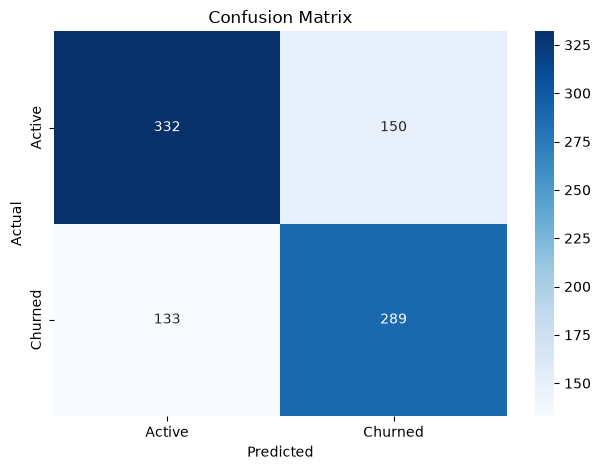

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = rfm[["Recency", "Frequency", "Monetary", "Revenue_per_Order", "Is_OneTime_Buyer"]]
y = rfm["Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Active","Churned"],
            yticklabels=["Active","Churned"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

for name, m in models.items():
    if name == "Logistic Regression":
        m.fit(X_train_scaled, y_train)
        pred = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
    
    from sklearn.metrics import accuracy_score
    print(f"{name}: {accuracy_score(y_test, pred):.2%}")

Random Forest: 68.69%
Gradient Boosting: 71.02%
XGBoost: 69.14%
Logistic Regression: 71.68%


In [13]:
rfm["Monetary_Rank"] = rfm["Monetary"].rank(pct=True)
rfm["Frequency_Rank"] = rfm["Frequency"].rank(pct=True)
rfm["High_Value"] = (rfm["Monetary"] > rfm["Monetary"].quantile(0.75)).astype(int)
rfm["Log_Frequency"] = np.log1p(rfm["Frequency"])
rfm["Log_Monetary"] = np.log1p(rfm["Monetary"])

X = rfm[["Recency", "Frequency", "Monetary",
          "Revenue_per_Order", "Is_OneTime_Buyer",
          "Monetary_Rank", "Frequency_Rank", 
          "High_Value", "Log_Frequency", "Log_Monetary"]]
y = rfm["Churned"]

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [200, 500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", f"{grid.best_score_:.2%}")

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("\nTest accuracy:", f"{accuracy_score(y_test, y_pred_best):.2%}")
print("\n", classification_report(y_test, y_pred_best))

Best params: {'C': 0.1, 'max_iter': 200, 'solver': 'liblinear'}
Best CV accuracy: 72.70%

Test accuracy: 71.79%

               precision    recall  f1-score   support

           0       0.73      0.75      0.74       482
           1       0.70      0.68      0.69       422

    accuracy                           0.72       904
   macro avg       0.72      0.72      0.72       904
weighted avg       0.72      0.72      0.72       904

